primer modelo de inicio


In [ ]:
#! pip install xxxx

import subprocess

# Installation on Google Colab
try:
    import google.colab
    subprocess.run(['python', '-m', 'pip', 'install', 'skorch' , 'torch'])
except ImportError:
    pass

In [ ]:
import torch
from torch import nn
import torch.nn.functional as F

In [ ]:
torch.manual_seed(0)
torch.cuda.manual_seed(0)

In [ ]:
import pandas as pd

df= pd.read_csv('data_no_mol_desc.tsv', sep = '\t')
df.head(100)


/tmp/ipykernel_485/3328083348.py:3: DtypeWarning: Columns (2,14) have mixed types. Specify dtype option on import or set low_memory=False.
  df= pd.read_csv('data_no_mol_desc.tsv', sep = '\t')


,id,molecule_id,name,formula,rt,smiles.std,inchi.std,inchikey.std,classyfire.kingdom,classyfire.superclass,...,B [%]_16,C [%]_16,D [%]_16,flow rate [ml/min]_16,t [min]_17,A [%]_17,B [%]_17,C [%]_17,D [%]_17,flow rate [ml/min]_17
0,1,0001_00001,epicatechin,C15H14O6,12.070000,C1C(C(OC2=CC(=CC(=C21)O)O)C3=CC(=C(C=C3)O)O)O,InChI=1S/C15H14O6/c16-8-4-11(18)9-6-13(20)15(2...,PFTAWBLQPZVEMU-UHFFFAOYSA-N,Organic compounds (CHEMONTID:0000000),Phenylpropanoids and polyketides (CHEMONTID:00...,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1,0001_00002,epicatechin gallate,C22H18O10,15.990000,C1C(C(OC2=CC(=CC(=C21)O)O)C3=CC(=C(C=C3)O)O)OC...,InChI=1S/C22H18O10/c23-11-6-14(25)12-8-19(32-2...,LSHVYAFMTMFKBA-UHFFFAOYSA-N,Organic compounds (CHEMONTID:0000000),Phenylpropanoids and polyketides (CHEMONTID:00...,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1,0001_00003,gallocatechin,C15H14O7,8.675000,C1C(C(OC2=CC(=CC(=C21)O)O)C3=CC(=C(C(=C3)O)O)O)O,InChI=1S/C15H14O7/c16-7-3-9(17)8-5-12(20)15(22...,XMOCLSLCDHWDHP-UHFFFAOYSA-N,Organic compounds (CHEMONTID:0000000),Phenylpropanoids and polyketides (CHEMONTID:00...,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1,0001_00004,"3,5-dihydroxybenzoic acid",C7H6O4,7.750000,C1=C(C=C(C=C1O)O)C(=O)O,InChI=1S/C7H6O4/c8-5-1-4(7(10)11)2-6(9)3-5/h1-...,UYEMGAFJOZZIFP-UHFFFAOYSA-N,Organic compounds (CHEMONTID:0000000),Benzenoids (CHEMONTID:0002448),...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1,0001_00005,4-hydroxybenzoic acid,C7H6O3,10.600000,C1=CC(=CC=C1C(=O)O)O,"InChI=1S/C7H6O3/c8-6-3-1-5(2-4-6)7(9)10/h1-4,8...",FJKROLUGYXJWQN-UHFFFAOYSA-N,Organic compounds (CHEMONTID:0000000),Benzenoids (CHEMONTID:0002448),...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,1,0001_00006,astringin,C20H22O9,14.200000,C1=CC(=C(C=C1C=CC2=CC(=CC(=C2)OC3C(C(C(C(O3)CO...,InChI=1S/C20H22O9/c21-9-16-17(25)18(26)19(27)2...,PERPNFLGJXUDDW-UHFFFAOYSA-N,Organic compounds (CHEMONTID:0000000),Phenylpropanoids and polyketides (CHEMONTID:00...,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,1,0001_00007,caftaric acid,C13H12O9,8.530000,C1=CC(=C(C=C1C=CC(=O)OC(C(C(=O)O)O)C(=O)O)O)O,InChI=1S/C13H12O9/c14-7-3-1-6(5-8(7)15)2-4-9(1...,SWGKAHCIOQPKFW-UHFFFAOYSA-N,Organic compounds (CHEMONTID:0000000),Phenylpropanoids and polyketides (CHEMONTID:00...,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,1,0001_00008,cis-piceid,C20H22O8,18.420000,C1=CC(=CC=C1C=CC2=CC(=CC(=C2)OC3C(C(C(C(O3)CO)...,InChI=1S/C20H22O8/c21-10-16-17(24)18(25)19(26)...,HSTZMXCBWJGKHG-UHFFFAOYSA-N,Organic compounds (CHEMONTID:0000000),Phenylpropanoids and polyketides (CHEMONTID:00...,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,1,0001_00009,cis-resveratrol,C14H12O3,20.370000,C1=CC(=CC=C1C=CC2=CC(=CC(=C2)O)O)O,InChI=1S/C14H12O3/c15-12-5-3-10(4-6-12)1-2-11-...,LUKBXSAWLPMMSZ-UHFFFAOYSA-N,Organic compounds (CHEMONTID:0000000),Phenylpropanoids and polyketides (CHEMONTID:00...,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,1,0001_00010,ellagic acid,C14H6O8,20.340000,C1=C2C3=C(C(=C1O)O)OC(=O)C4=CC(=C(C(=C43)OC2=O...,InChI=1S/C14H6O8/c15-5-1-3-7-8-4(14(20)22-11(7...,AFSDNFLWKVMVRB-UHFFFAOYSA-N,Organic compounds (CHEMONTID:0000000),Phenylpropanoids and polyketides (CHEMONTID:00...,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Crear el array de pringer prints

In [ ]:
!pip install rdkit


In [ ]:

import pandas as pd
import numpy as np
from rdkit import Chem, DataStructs
from rdkit.Chem import rdFingerprintGenerator

# Cargar datos
df = pd.read_csv('data_no_mol_desc.tsv', sep='\t', low_memory=False)

# Crear generador Morgan moderno
morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)

def smiles_to_morgan(smiles):
    if pd.isna(smiles):
        return None

    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None

    fp = morgan_gen.GetFingerprint(mol)
    arr = np.zeros((2048,), dtype=np.int8)
    DataStructs.ConvertToNumpyArray(fp, arr)
    return arr

# Guardarlo directamente en df
df = df.copy()
df.loc[:, "fingerprint"] = df["smiles.std"].apply(smiles_to_morgan)


# Ver algunas filas
print(df[["smiles.std", "fingerprint"]].head())

[10:08:01] WARNING: not removing hydrogen atom without neighbors
[10:08:01] WARNING: not removing hydrogen atom without neighbors
[10:08:01] WARNING: not removing hydrogen atom without neighbors
[10:08:01] WARNING: not removing hydrogen atom without neighbors
[10:08:01] WARNING: not removing hydrogen atom without neighbors
[10:08:01] WARNING: not removing hydrogen atom without neighbors
[10:08:01] WARNING: not removing hydrogen atom without neighbors
[10:08:02] WARNING: not removing hydrogen atom without neighbors
[10:08:02] WARNING: not removing hydrogen atom without neighbors
[10:08:02] WARNING: not removing hydrogen atom without neighbors
[10:08:02] WARNING: not removing hydrogen atom without neighbors
[10:08:02] WARNING: not removing hydrogen atom without neighbors
[10:08:02] WARNING: not removing hydrogen atom without neighbors
[10:08:02] WARNING: not removing hydrogen atom without neighbors
[10:08:02] WARNING: not removing hydrogen atom without neighbors
[10:08:03] WARNING: not r

                                          smiles.std  \
0      C1C(C(OC2=CC(=CC(=C21)O)O)C3=CC(=C(C=C3)O)O)O   
1  C1C(C(OC2=CC(=CC(=C21)O)O)C3=CC(=C(C=C3)O)O)OC...   
2   C1C(C(OC2=CC(=CC(=C21)O)O)C3=CC(=C(C(=C3)O)O)O)O   
3                            C1=C(C=C(C=C1O)O)C(=O)O   
4                               C1=CC(=CC=C1C(=O)O)O   

                                         fingerprint  
0  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...  
1  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...  
2  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...  
3  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...  
4  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...  


In [ ]:
print(type(df.loc[0, "fingerprint"]))
print(len(df.loc[0, "fingerprint"]))
print(sum(df.loc[0, "fingerprint"]))
print(df.loc[0, "fingerprint"][:1000])


<class 'numpy.ndarray'>
2048
35
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0

In [ ]:
n_none = df["fingerprint"].isna().sum()
print("Número de fingerprints no generados:", n_none)

Número de fingerprints no generados: 0


analisis de dataset original y creacion de datos de entrenamiento

In [ ]:
exp_por_config = df.groupby("id").size().reset_index(name="n_experimentos")

pd.set_option('display.max_rows', None)
print(exp_por_config)

      id  n_experimentos
0      1              76
1      2             441
2      3             105
3      4             226
4      5              88
5      6              32
6      7             217
7      8              49
8      9             573
9     10             112
10    13              48
11    14              50
12    15             155
13    16              48
14    19             420
15    20             179
16    21              65
17    23              79
18    25             121
19    27             407
20    28              54
21    29              55
22    30              55
23    31              48
24    32              57
25    33              56
26    34              42
27    36              71
28    37              32
29    38              80
30    39              69
31    40             102
32    41              94
33    42              74
34    44             818
35    45             665
36    46              15
37    47             216
38    48             916


In [ ]:
config_max = exp_por_config.loc[exp_por_config["n_experimentos"].idxmax()]

print(config_max)

id                  186
n_experimentos    83738
Name: 172, dtype: int64


In [ ]:
df.head()

,id,molecule_id,name,formula,rt,smiles.std,inchi.std,inchikey.std,classyfire.kingdom,classyfire.superclass,...,C [%]_16,D [%]_16,flow rate [ml/min]_16,t [min]_17,A [%]_17,B [%]_17,C [%]_17,D [%]_17,flow rate [ml/min]_17,fingerprint
0,1,0001_00001,epicatechin,C15H14O6,12.070,C1C(C(OC2=CC(=CC(=C21)O)O)C3=CC(=C(C=C3)O)O)O,InChI=1S/C15H14O6/c16-8-4-11(18)9-6-13(20)15(2...,PFTAWBLQPZVEMU-UHFFFAOYSA-N,Organic compounds (CHEMONTID:0000000),Phenylpropanoids and polyketides (CHEMONTID:00...,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,1,0001_00002,epicatechin gallate,C22H18O10,15.990,C1C(C(OC2=CC(=CC(=C21)O)O)C3=CC(=C(C=C3)O)O)OC...,InChI=1S/C22H18O10/c23-11-6-14(25)12-8-19(32-2...,LSHVYAFMTMFKBA-UHFFFAOYSA-N,Organic compounds (CHEMONTID:0000000),Phenylpropanoids and polyketides (CHEMONTID:00...,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,1,0001_00003,gallocatechin,C15H14O7,8.675,C1C(C(OC2=CC(=CC(=C21)O)O)C3=CC(=C(C(=C3)O)O)O)O,InChI=1S/C15H14O7/c16-7-3-9(17)8-5-12(20)15(22...,XMOCLSLCDHWDHP-UHFFFAOYSA-N,Organic compounds (CHEMONTID:0000000),Phenylpropanoids and polyketides (CHEMONTID:00...,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
3,1,0001_00004,"3,5-dihydroxybenzoic acid",C7H6O4,7.750,C1=C(C=C(C=C1O)O)C(=O)O,InChI=1S/C7H6O4/c8-5-1-4(7(10)11)2-6(9)3-5/h1-...,UYEMGAFJOZZIFP-UHFFFAOYSA-N,Organic compounds (CHEMONTID:0000000),Benzenoids (CHEMONTID:0002448),...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
4,1,0001_00005,4-hydroxybenzoic acid,C7H6O3,10.600,C1=CC(=CC=C1C(=O)O)O,"InChI=1S/C7H6O3/c8-6-3-1-5(2-4-6)7(9)10/h1-4,8...",FJKROLUGYXJWQN-UHFFFAOYSA-N,Organic compounds (CHEMONTID:0000000),Benzenoids (CHEMONTID:0002448),...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


In [ ]:
df_186 = df[df["id"] == 186].copy()
df_186.head()

,id,molecule_id,name,formula,rt,smiles.std,inchi.std,inchikey.std,classyfire.kingdom,classyfire.superclass,...,C [%]_16,D [%]_16,flow rate [ml/min]_16,t [min]_17,A [%]_17,B [%]_17,C [%]_17,D [%]_17,flow rate [ml/min]_17,fingerprint
24633,186,0186_00001,NaN,C3H8N2S,1.558333,CCSC(=N)N,"InChI=1S/C3H8N2S/c1-2-6-3(4)5/h2H2,1H3,(H3,4,5)",VFIZBHJTOHUOEK-UHFFFAOYSA-N,Organic compounds (CHEMONTID:0000000),Organosulfur compounds (CHEMONTID:0000004),...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
24634,186,0186_00002,NaN,C19H25Cl2N3O3,11.463333,COC(=O)N1CCN(C(C1)CN2CCCC2)C(=O)CC3=CC(=C(C=C3...,InChI=1S/C19H25Cl2N3O3/c1-27-19(26)23-8-9-24(1...,HJUAKZYKCANOOZ-UHFFFAOYSA-N,Organic compounds (CHEMONTID:0000000),Benzenoids (CHEMONTID:0002448),...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
24635,186,0186_00003,NaN,C17H27N3O4S,9.845000,CCN1CCCC1CNC(=O)C2=CC(=C(C=C2OC)N)S(=O)(=O)CC,InChI=1S/C17H27N3O4S/c1-4-20-8-6-7-12(20)11-19...,NTJOBXMMWNYJFB-UHFFFAOYSA-N,Organic compounds (CHEMONTID:0000000),Benzenoids (CHEMONTID:0002448),...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
24636,186,0186_00004,NaN,C9H7NO2,9.726667,C1=CC2=C(C=CNC2=O)C(=C1)O,InChI=1S/C9H7NO2/c11-8-3-1-2-7-6(8)4-5-10-9(7)...,LFUJIPVWTMGYDG-UHFFFAOYSA-N,Organic compounds (CHEMONTID:0000000),Organoheterocyclic compounds (CHEMONTID:0000002),...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
24637,186,0186_00005,NaN,C15H20N2O2,9.650000,C1CN(CCC12CNC(=O)O2)CCC3=CC=CC=C3,InChI=1S/C15H20N2O2/c18-14-16-12-15(19-14)7-10...,FVNFBBAOMBJTST-UHFFFAOYSA-N,Organic compounds (CHEMONTID:0000000),Organoheterocyclic compounds (CHEMONTID:0000002),...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


In [ ]:
import json

df_186_guardar = df_186.copy()
df_186_guardar["fingerprint"] = df_186_guardar["fingerprint"].apply(
    lambda x: json.dumps(np.asarray(x, dtype=int).tolist())
)

df_186_guardar.to_csv("experiment_186.tsv", sep="\t", index=False)

In [ ]:

from google.colab import files
files.download("experiment_186.tsv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:


datos_186 = df_186[["rt", "fingerprint"]].copy()

print(datos_186.head())

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

              rt                                        fingerprint
24633   1.558333  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...
24634  11.463333  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...
24635   9.845000  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...
24636   9.726667  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...
24637   9.650000  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...


In [ ]:
df_186["rt"].describe()

,rt
count,83738.000000
mean,13.091164
std,3.493489
min,0.005000
25%,10.965000
50%,12.825000
75%,15.145000
max,24.528333


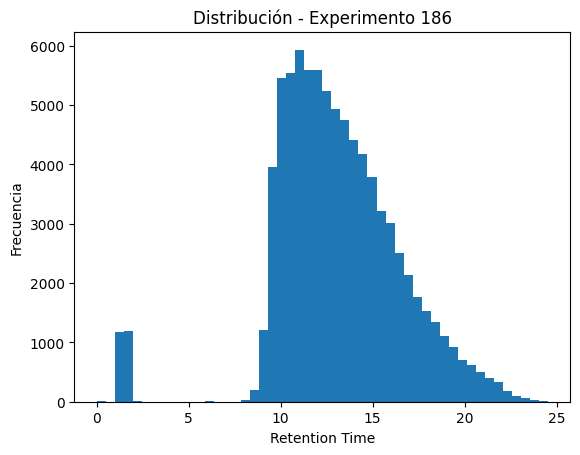

In [ ]:
import matplotlib.pyplot as plt

plt.hist(rt, bins=50)
plt.xlabel("Retention Time")
plt.ylabel("Frecuencia")
plt.title("Distribución - Experimento 186")
plt.show()

In [ ]:
X_186 = np.stack(datos_186["fingerprint"].values).astype(np.float32)
y_186 = datos_186["rt"].values.astype(np.float32)

print(X_186.shape)
print(y_186.shape)

(83738, 2048)
(83738,)


In [ ]:
print("Número de moléculas del experimento 186:", len(df_186))
print("Shape de X:", X_186.shape)
print("Shape de y:", y_186.shape)
print("Primer rt:", y_186[0])
print("Primer fingerprint:", X_186[0][:20])

Número de moléculas del experimento 186: 83738
Shape de X: (83738, 2048)
Shape de y: (83738,)
Primer rt: 1.5583333
Primer fingerprint: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [ ]:
from sklearn.model_selection import train_test_split
X = X_186
y = y_186

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
X_train_t = torch.tensor(X_train, dtype=torch.float32)
X_test_t = torch.tensor(X_test, dtype=torch.float32)

y_train_t = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
y_test_t = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

In [ ]:
print(X_train_t.shape)
print(X_test_t.shape)
print(y_train_t.shape)
print(y_test_t.shape)

torch.Size([66990, 2048])
torch.Size([16748, 2048])
torch.Size([66990, 1])
torch.Size([16748, 1])


In [ ]:
import torch.nn as nn

class RetentionTimeNN001(nn.Module):
    def __init__(self, input_dim=2048):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        return self.network(x)

In [ ]:
model = RetentionTimeNN(input_dim=X.shape[1])

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [ ]:
num_epochs = 100

for epoch in range(num_epochs):
    model.train()  # modo entrenamiento

    # Predicción
    y_pred = model(X_train_t)

    # Calcular pérdida
    loss = criterion(y_pred, y_train_t)

    # Poner gradientes a cero
    optimizer.zero_grad()

    # Backpropagation
    loss.backward()

    # Actualizar pesos
    optimizer.step()

    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}")

Epoch [10/100], Loss: 111.6858
Epoch [20/100], Loss: 31.6632
Epoch [30/100], Loss: 12.9752
Epoch [40/100], Loss: 10.0698
Epoch [50/100], Loss: 8.9632
Epoch [60/100], Loss: 7.6144
Epoch [70/100], Loss: 6.5983
Epoch [80/100], Loss: 5.8464
Epoch [90/100], Loss: 5.2613
Epoch [100/100], Loss: 4.7656


In [ ]:
model.eval()

with torch.no_grad():
    y_test_pred_t = model(X_test_t)

y_test_pred = y_test_pred_t.numpy().flatten()
y_test_real = y_test_t.numpy().flatten()

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test_real, y_test_pred))
mae = mean_absolute_error(y_test_real, y_test_pred)
r2 = r2_score(y_test_real, y_test_pred)

print("RMSE:", rmse)
print("MAE:", mae)
print("R2:", r2)

RMSE: 2.1984883750554394
MAE: 1.570250153541565
R2: 0.5984257459640503
